# EEG-CogState — Sprint 1 : Exploration du signal brut

**Objectif du Sprint 1** (cahier des charges) : charger un dataset EEG, afficher le signal brut, produire une visualisation simple.

**Dataset** : STEW (Simultaneous Task EEG Workload) — 48 sujets, 14 canaux, 128 Hz.

Ce notebook ne fait **ni** prétraitement avancé, **ni** machine learning : on se concentre uniquement sur le chargement et la visualisation, conformément au périmètre du sprint.

## 1. Imports et configuration

On importe nos modules du dossier `src/`. La cellule ci-dessous ajoute la racine du projet au chemin Python pour que les imports fonctionnent depuis `notebooks/`.

In [9]:
import sys
from pathlib import Path

# Ajoute la racine du projet au chemin pour importer src/
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, io_eeg, viz

print("Frequence d'echantillonnage :", config.SAMPLING_RATE, "Hz")
print("Nombre de canaux :", config.N_CHANNELS)
print("Classes :", config.CLASSES)

Frequence d'echantillonnage : 128 Hz
Nombre de canaux : 14
Classes : ['relaxation', 'concentration']


## 2. Recensement des fichiers disponibles

On liste tous les fichiers EEG présents dans `data/raw/`.

> **⚠️ Si le tableau est vide** : téléchargez le dataset STEW depuis IEEE DataPort et placez les fichiers `.txt` (ex. `sub01_lo.txt`, `sub01_hi.txt`, ...) dans le dossier `data/raw/`.

In [10]:
catalogue = io_eeg.list_recordings()
print(f"{len(catalogue)} fichier(s) trouve(s)\n")
catalogue

8 fichier(s) trouve(s)



,path,filename,subject,suffix,label
0,C:\Users\user\EEG-CogState-Sprint1\data\raw\su...,sub10_lo.txt,10,lo,relaxation
1,C:\Users\user\EEG-CogState-Sprint1\data\raw\su...,sub10_lo.txt,10,lo,relaxation
2,C:\Users\user\EEG-CogState-Sprint1\data\raw\su...,sub11_hi.txt,11,hi,concentration
3,C:\Users\user\EEG-CogState-Sprint1\data\raw\su...,sub11_hi.txt,11,hi,concentration
4,C:\Users\user\EEG-CogState-Sprint1\data\raw\su...,sub11_lo.txt,11,lo,relaxation
5,C:\Users\user\EEG-CogState-Sprint1\data\raw\su...,sub11_lo.txt,11,lo,relaxation
6,C:\Users\user\EEG-CogState-Sprint1\data\raw\su...,sub12_hi.txt,12,hi,concentration
7,C:\Users\user\EEG-CogState-Sprint1\data\raw\su...,sub12_hi.txt,12,hi,concentration


In [11]:
# Repartition des fichiers par etat cognitif
if not catalogue.empty:
    print(catalogue["label"].value_counts())
    print(f"\nNombre de sujets distincts : {catalogue['subject'].nunique()}")

label
relaxation       4
concentration    4
Name: count, dtype: int64

Nombre de sujets distincts : 3


## 3. Chargement d'un enregistrement

On charge le premier fichier et on inspecte sa structure : dimensions, canaux, premières valeurs.

In [12]:
# On prend le premier fichier du catalogue
sample_path = catalogue.iloc[0]["path"]

df = io_eeg.load_recording(sample_path)
meta = io_eeg.parse_filename(sample_path)

print("Fichier :", meta["filename"])
print("Etat    :", meta["label"])
print("Forme   :", df.shape, "(echantillons x canaux)")
print("Duree   :", round(len(df) / config.SAMPLING_RATE, 1), "secondes")
df.head()

Fichier : sub10_lo.txt
Etat    : relaxation
Forme   : (19200, 14) (echantillons x canaux)
Duree   : 150.0 secondes


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
0,4183.08,4106.15,4086.15,4164.62,4522.56,4029.74,4279.49,4281.03,4363.59,4006.67,4553.85,4678.97,4626.67,4668.72
1,4183.08,4107.69,4087.18,4165.13,4522.05,4028.72,4279.49,4283.08,4366.15,4011.28,4558.46,4676.92,4629.74,4672.31
2,4184.10,4108.72,4086.15,4165.13,4520.51,4028.72,4275.90,4282.05,4367.18,4008.21,4560.00,4674.87,4626.15,4673.33
3,4184.10,4105.13,4087.69,4167.18,4521.54,4030.26,4275.90,4278.97,4362.05,4003.59,4554.36,4674.87,4620.51,4670.77
4,4183.08,4099.49,4084.62,4166.67,4517.44,4026.67,4271.79,4276.92,4356.41,4003.08,4550.77,4673.33,4622.56,4668.72


In [13]:
# Statistiques descriptives par canal (amplitude en microvolts)
df.describe().round(2)

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
count,19200.00,19200.00,19200.00,19200.00,19200.00,19200.00,19200.00,19200.00,19200.00,19200.00,19200.00,19200.00,19200.00,19200.00
mean,4208.09,4099.21,4112.39,4198.35,4556.44,4051.83,4290.17,4315.58,4369.12,4020.99,4557.65,4705.44,4651.71,4698.92
std,78.26,66.61,30.34,31.88,32.15,30.54,29.76,32.98,26.71,31.37,48.03,60.84,32.83,32.95
min,4047.69,3890.26,4048.72,4122.56,4473.33,3971.79,4200.51,4215.90,4296.92,3925.64,4029.23,4605.64,4564.62,4614.87
25%,4163.59,4058.97,4100.00,4182.05,4541.03,4039.49,4278.97,4300.00,4355.90,4007.69,4538.97,4667.69,4635.90,4684.10
50%,4191.28,4094.87,4107.69,4193.85,4552.82,4048.21,4284.62,4311.79,4366.15,4016.92,4556.92,4686.67,4648.21,4695.38
75%,4230.26,4127.18,4116.92,4207.18,4563.08,4056.41,4294.36,4323.08,4377.95,4025.64,4575.90,4720.00,4659.49,4705.13
max,4726.67,4568.21,4337.95,4389.23,4762.05,4261.03,4497.95,4553.33,4542.56,4268.21,4771.28,5015.90,4887.18,4937.44


## 4. Visualisation du signal brut

On affiche les premières secondes de quelques canaux. C'est le cœur du livrable Sprint 1.

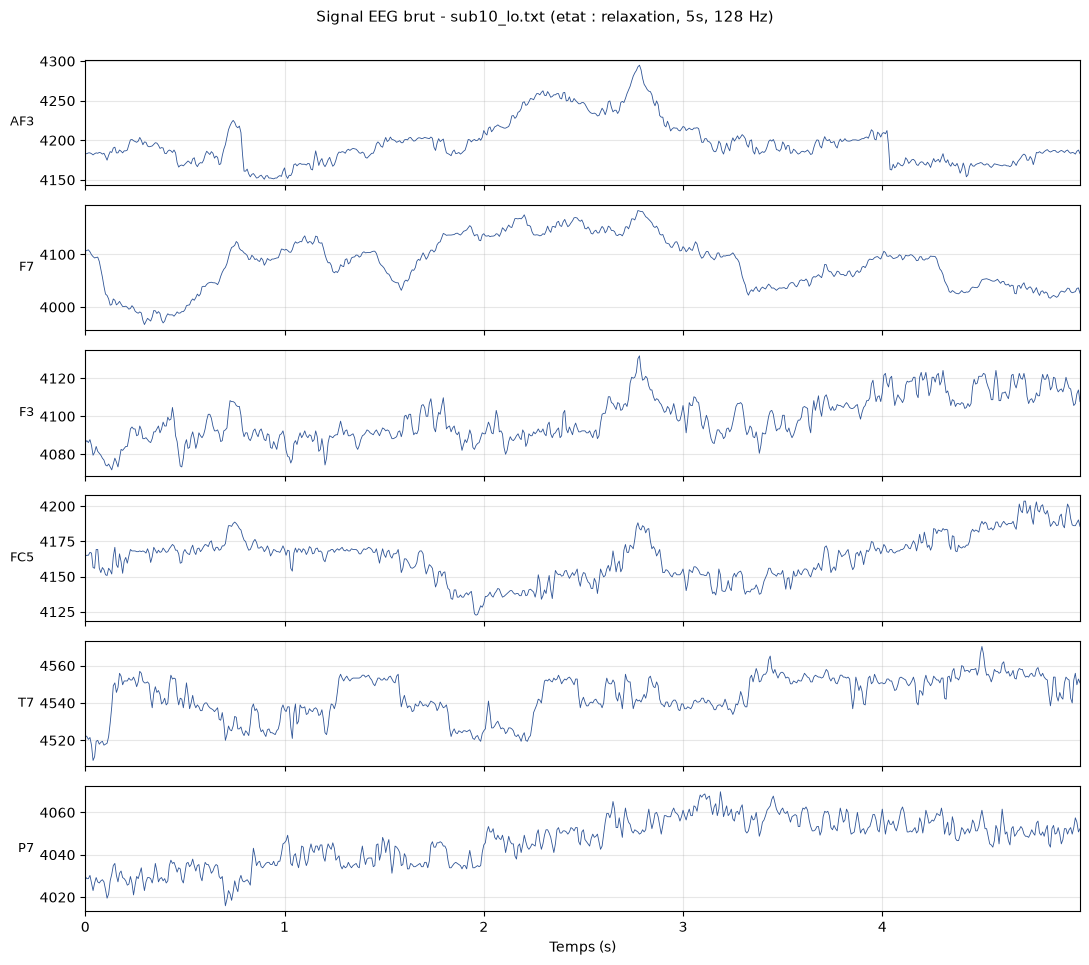

In [14]:
fig = viz.plot_raw_signals(sample_path, n_seconds=5, n_channels=6)
plt.show()

## 5. Analyse spectrale (PSD)

La densité spectrale de puissance révèle quelles bandes de fréquence dominent.
Rappel des correspondances :
- pic vers **10 Hz** (alpha) → repos / relaxation
- énergie vers **20 Hz** (bêta) → concentration / effort mental

Le canal **O1** (occipital) est un bon choix pour observer l'activité alpha.

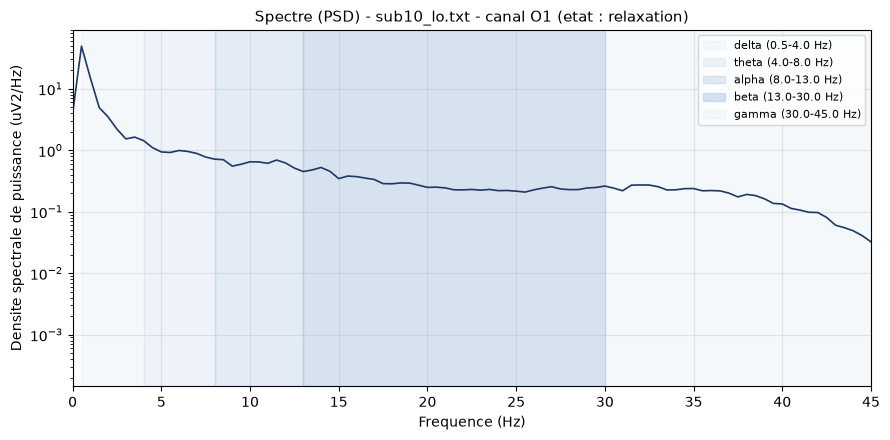

In [15]:
fig = viz.plot_psd(sample_path, channel="O1")
plt.show()

## 6. Comparaison entre deux états

Si on dispose des deux conditions pour un même sujet (repos `lo` vs multitâche `hi`),
on compare leurs spectres côte à côte. C'est ici qu'on observe — ou non —
la signature spectrale attendue.

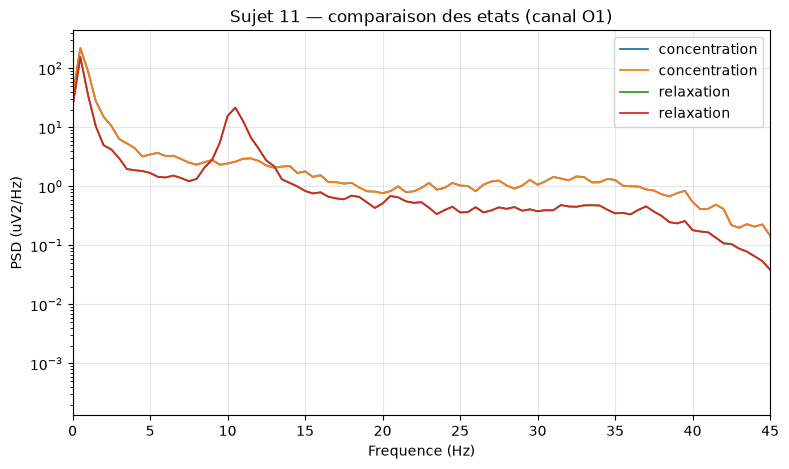

In [16]:
from scipy.signal import welch

if not catalogue.empty:
    # Cherche un sujet ayant les deux conditions
    subj = catalogue.groupby("subject")["suffix"].nunique()
    both = subj[subj >= 2].index

    if len(both) > 0:
        s = both[0]
        rows = catalogue[catalogue["subject"] == s]
        fig, ax = plt.subplots(figsize=(9, 5))
        for _, r in rows.iterrows():
            d = io_eeg.load_recording(r["path"])
            f, psd = welch(d["O1"].values, fs=config.SAMPLING_RATE, nperseg=256)
            ax.semilogy(f, psd, linewidth=1.3, label=r["label"])
        ax.set_xlim(0, 45)
        ax.set_xlabel("Frequence (Hz)")
        ax.set_ylabel("PSD (uV2/Hz)")
        ax.set_title(f"Sujet {s} — comparaison des etats (canal O1)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()
    else:
        print("Aucun sujet avec les deux conditions dans data/raw/.")

## ✅ Bilan du Sprint 1

À ce stade, on sait :
- recenser et charger les fichiers EEG STEW ;
- inspecter leur structure (14 canaux, durée, amplitudes) ;
- visualiser le signal temporel brut ;
- observer le spectre et les bandes de fréquence.

**Prochaine étape (Sprint 2)** : prétraitement — filtrage passe-bande, suppression du bruit secteur (notch 50 Hz), et segmentation du signal en *epochs*.